<a href="https://colab.research.google.com/github/seo104/26-2-ESAA/blob/main/YB_1009(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [15]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

confusion_matrix(y, y_pred)

array([[337,  20],
       [ 30, 182]])

**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정확도는 전체 데이터 중 실제 정답과 예측 결과가 일치한 데이터의 비율

In [16]:
from sklearn.metrics import accuracy_score

accuracy_score(y, y_pred)

0.9121265377855887

현재 데이터에서는 약 91.21%로, 전체 데이터의 약 91%를 올바르게 분류했다.

**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정밀도는 양성(악성)으로 예측한 데이터 중 실제 양성인 데이터의 비율

In [17]:
from sklearn.metrics import precision_score

precision_score(y, y_pred)

0.900990099009901

데이터의 정밀도는 약 90.10%로, 악성이라고 예측한 데이터 중 약 90%가 실제 악성이었다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

재현율은 실제 양성(악성) 데이터 중 양성으로 올바르게 예측한 데이터의 비율

In [18]:
from sklearn.metrics import recall_score

recall_score(y, y_pred)

0.8584905660377359

재현율은 약 85.85%로, 실제 악성 데이터 중 약 86%를 찾아냈다.

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

F1 Score는 정밀도와 재현율의 조화평균

In [19]:
from sklearn.metrics import f1_score

f1_score(y, y_pred)

0.8792270531400966

F1 score는 약 87.92%로, 두 지표를 종합했을 때 비교적 높은 분류 성능을 보인다.

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [20]:
from sklearn.preprocessing import Binarizer

pred_proba = model_lor.predict_proba(X)

binarizer = Binarizer(threshold=0.1)
y_pred2 = binarizer.fit_transform(
    pred_proba[:, 0].reshape(-1, 1)
).astype(int).ravel()

In [21]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
print(confusion_matrix(y, y_pred2))
print("정확도:", accuracy_score(y, y_pred2))
print("정밀도:", precision_score(y, y_pred2, zero_division=0))
print("재현율:", recall_score(y, y_pred2))
print("F1 Score:", f1_score(y, y_pred2))

[[  1 356]
 [139  73]]
정확도: 0.13005272407732865
정밀도: 0.17016317016317017
재현율: 0.3443396226415094
F1 Score: 0.22776911076443057


**ROC 곡선 시각화**

In [22]:
from sklearn.metrics import roc_curve


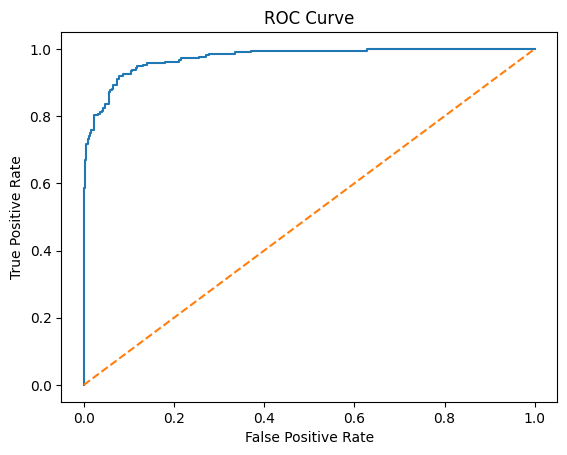

In [23]:
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(
    y, model_lor.predict_proba(X)[:, 1]
)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [24]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, model_lor.predict_proba(X)[:, 1])

np.float64(0.974076423022039)

ROC AUC는 다양한 분류 기준에서 모델이 양성과 음성을 구분하는 능력을 나타낸다. 해당 값이 약 0.974로 1에 가까움으로 높은 구분 성능을 보인다.